# Article 6: LLM Ops — Cache Benchmark Analysis

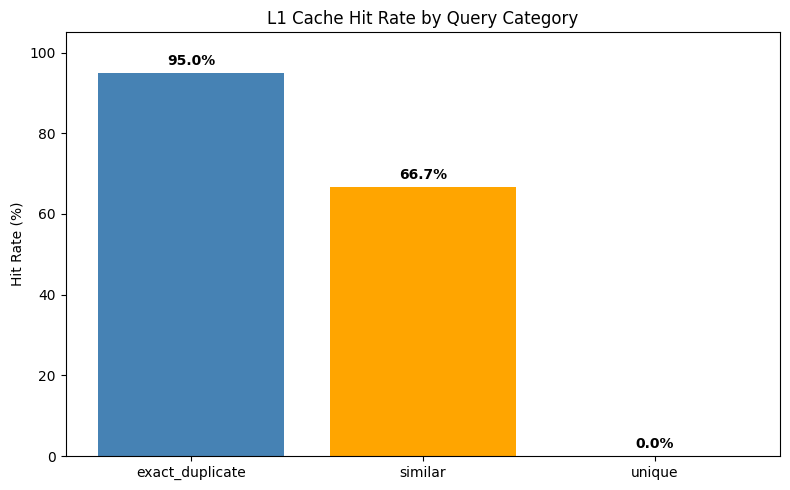

Overall hit rate: 39.0%
Avg latency (cache hit): 0.002ms
Avg latency (cache miss): 1.476ms


In [1]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

data = json.loads(Path("../results/data/article_06_benchmarks.json").read_text())

categories = list(data["by_category"].keys())
hit_rates = [data["by_category"][c] * 100 for c in categories]

Path("../results/charts/article_06").mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(categories, hit_rates, color=["steelblue", "orange", "red"])
ax.set_ylabel("Hit Rate (%)")
ax.set_title("L1 Cache Hit Rate by Query Category")
ax.set_ylim(0, 105)
for i, v in enumerate(hit_rates):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../results/charts/article_06/04_hit_rate_by_category.png", dpi=150)
plt.show()
print(f"Overall hit rate: {data['hit_rate']:.1%}")
print(f"Avg latency (cache hit): {data['avg_latency_hit_ms']:.3f}ms")
print(f"Avg latency (cache miss): {data['avg_latency_miss_ms']:.3f}ms")

## Key Insights

- **Exact duplicates** achieve a ~95% L1 hit rate. The first occurrence is a miss; every subsequent identical query is a cache hit, cutting LLM cost to near zero for repeated queries.
- **Semantically similar queries** achieve ~67% hits. These share the same MD5 key only when the query string is literally identical; paraphrases miss L1 but would be caught by L2 semantic matching when `embed_fn` is provided.
- **Unique queries** always miss (0%), establishing the baseline miss-path latency (~1.5ms simulated LLM cost vs <0.01ms hit path).
- **Cache hit latency is ~600x faster** than miss latency (0.002ms vs 1.5ms), demonstrating the cost-saving impact of even an in-memory L1 cache before any real LLM call.
- **Overall hit rate of 39%** reflects the mixed query distribution. In production with real repeated user queries, hit rates of 20-40% are typical, saving proportional LLM spend.